In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [3]:
import pandas as pd

df = pd.read_csv('filtered_features_s20.csv')

print("Columns in file:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns in file:
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row', 'MagpieData maximum Row', 'MagpieData range Row', 'MagpieData mean Row', 'MagpieData mode Row', 'MagpieData minimum CovalentRadius', 'MagpieData maximum CovalentRadius', 'MagpieData range CovalentRadius', 'MagpieData mean CovalentRadius', 'MagpieData mode CovalentRadius', 'MagpieData minimum Electronegativity', 'MagpieData

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData mode MendeleevNumber,...,MagpieData mode GSbandgap,MagpieData minimum GSmagmom,MagpieData maximum GSmagmom,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
1,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
2,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
3,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
4,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0


In [5]:
import pandas as pd

df = pd.read_csv('filtered_features_s20.csv')

print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

Shape: (4564, 96)

Columns:
0 -> MagpieData minimum Number
1 -> MagpieData maximum Number
2 -> MagpieData range Number
3 -> MagpieData mean Number
4 -> MagpieData mode Number
5 -> MagpieData minimum MendeleevNumber
6 -> MagpieData maximum MendeleevNumber
7 -> MagpieData range MendeleevNumber
8 -> MagpieData mean MendeleevNumber
9 -> MagpieData mode MendeleevNumber
10 -> MagpieData minimum MeltingT
11 -> MagpieData maximum MeltingT
12 -> MagpieData range MeltingT
13 -> MagpieData mean MeltingT
14 -> MagpieData mode MeltingT
15 -> MagpieData minimum Column
16 -> MagpieData maximum Column
17 -> MagpieData range Column
18 -> MagpieData mean Column
19 -> MagpieData avg_dev Column
20 -> MagpieData mode Column
21 -> MagpieData minimum Row
22 -> MagpieData maximum Row
23 -> MagpieData range Row
24 -> MagpieData mean Row
25 -> MagpieData mode Row
26 -> MagpieData minimum CovalentRadius
27 -> MagpieData maximum CovalentRadius
28 -> MagpieData range CovalentRadius
29 -> MagpieData mean CovalentRa

In [6]:
import os

files = [f for f in os.listdir('.') if f.lower().endswith('.csv')]

print("CSV files in current folder:\n")
for f in files:
    print(f)

CSV files in current folder:

cleaned_cp_dataset.csv
cleaned_materials_dataset.csv
covid_19_india.csv
covid_vaccine_statewise.csv
filtered_features_s20.csv
matminer_deml_features.csv
matminer_magpie_features.csv
perovskites_data.csv
StatewiseTestingDetails.csv


In [7]:
import pandas as pd

for file in ['cleaned_materials_dataset.csv', 'cleaned_cp_dataset.csv']:
    temp = pd.read_csv(file)
    print("\n" + "="*70)
    print(file)
    print("Shape:", temp.shape)
    print("Columns:")
    print(temp.columns.tolist())


cleaned_materials_dataset.csv
Shape: (4719, 5)
Columns:
['Material_ID', 'Formula', 'Bandgap', 'Formation_Energy', 'Volume']

cleaned_cp_dataset.csv
Shape: (4564, 3)
Columns:
['formula', 'T', 'Cp']


In [8]:
import pandas as pd

features = pd.read_csv('filtered_features_s20.csv')
materials = pd.read_csv('cleaned_materials_dataset.csv')

print("Features:", features.shape)
print("Materials:", materials.shape)

print("\nMaterials sample:")
display(materials.head())

print("\nBandgap information:")
print(materials['Bandgap'].describe())

print("\nMissing Bandgap:", materials['Bandgap'].isna().sum())

Features: (4564, 96)
Materials: (4719, 5)

Materials sample:


,Material_ID,Formula,Bandgap,Formation_Energy,Volume
0,mp-1183115,AcAlO3,4.1024,-3.690019,57.451413
1,mp-1183052,AcBO3,0.8071,-2.475390,51.548126
2,mp-866101,AcCrO3,2.0031,-3.138972,61.362845
3,mp-864606,AcCuO3,0.0000,-2.422892,59.929387
4,mp-861502,AcFeO3,1.0084,-2.771539,61.797311



Bandgap information:
count    4719.000000
mean        1.122439
std         1.574498
min         0.000000
25%         0.000000
50%         0.000000
75%         2.079350
max         8.059800
Name: Bandgap, dtype: float64

Missing Bandgap: 0


In [9]:
magpie = pd.read_csv('matminer_magpie_features.csv')

print("Shape:", magpie.shape)
print("\nColumns:")
print(magpie.columns.tolist())

print("\nFirst 5 rows:")
display(magpie.head())

Shape: (4564, 132)

Columns:
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row', 'MagpieData 

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,5.0,8.0,3.0,6.8,1.44,8.0,72.0,87.0,15.0,81.0,...,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,73.92,12.0
1,5.0,8.0,3.0,6.8,1.44,8.0,72.0,87.0,15.0,81.0,...,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,73.92,12.0
2,5.0,8.0,3.0,6.8,1.44,8.0,72.0,87.0,15.0,81.0,...,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,73.92,12.0
3,5.0,8.0,3.0,6.8,1.44,8.0,72.0,87.0,15.0,81.0,...,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,73.92,12.0
4,5.0,8.0,3.0,6.8,1.44,8.0,72.0,87.0,15.0,81.0,...,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,73.92,12.0


In [10]:
import pandas as pd

perov = pd.read_csv('perovskites_data.csv')

print("Shape:", perov.shape)
print("\nColumns:")
print(perov.columns.tolist())

print("\nFirst 5 rows:")
display(perov.head())

Shape: (4719, 5)

Columns:
['Material_ID', 'Formula', 'Bandgap', 'Formation_Energy', 'Volume']

First 5 rows:


,Material_ID,Formula,Bandgap,Formation_Energy,Volume
0,mp-1183115,AcAlO3,4.1024,-3.690019,57.451413
1,mp-1183052,AcBO3,0.8071,-2.475390,51.548126
2,mp-866101,AcCrO3,2.0031,-3.138972,61.362845
3,mp-864606,AcCuO3,0.0000,-2.422892,59.929387
4,mp-861502,AcFeO3,1.0084,-2.771539,61.797311


In [11]:
import pandas as pd

filtered = pd.read_csv('filtered_features_s20.csv')
magpie = pd.read_csv('matminer_magpie_features.csv')

missing = [col for col in filtered.columns if col not in magpie.columns]

print("Filtered feature columns:", len(filtered.columns))
print("Magpie feature columns:", len(magpie.columns))
print("Missing columns:", len(missing))

if missing:
    print("\nMissing columns:")
    print(missing)
else:
    print("\n✅ All 96 filtered features exist in the 132-column Magpie dataset.")

Filtered feature columns: 96
Magpie feature columns: 132
Missing columns: 0

✅ All 96 filtered features exist in the 132-column Magpie dataset.


In [13]:
import pandas as pd
import numpy as np

filtered = pd.read_csv('filtered_features_s20.csv')
magpie = pd.read_csv('matminer_magpie_features.csv')

# Compare the 96 selected columns row-by-row
same = True
differences = []

for col in filtered.columns:
    a = filtered[col].to_numpy()
    b = magpie[col].to_numpy()
    
    if not np.allclose(a, b, equal_nan=True):
        same = False
        differences.append(col)

print("Same row order and values:", same)
print("Columns with differences:", len(differences))

if differences:
    print(differences[:20])

Same row order and values: True
Columns with differences: 0


In [14]:
import pandas as pd

materials = pd.read_csv('cleaned_materials_dataset.csv')

# Check for duplicate formulas
print("Total materials:", len(materials))
print("Unique formulas:", materials['Formula'].nunique())

print("\nDuplicate formulas:", materials['Formula'].duplicated().sum())

# Show rows around the end
print("\nLast 5 materials:")
display(materials.tail())

Total materials: 4719
Unique formulas: 2773

Duplicate formulas: 1946

Last 5 materials:


,Material_ID,Formula,Bandgap,Formation_Energy,Volume
4714,mp-1183045,ZrTiO3,0.0000,-2.729425,57.472192
4715,mp-1183044,ZrTlO3,0.0000,-2.454293,74.759243
4716,mp-1246572,ZrWN3,0.0000,-1.001812,272.960747
4717,mp-1016883,ZrZnO3,0.0000,-2.246558,71.115505
4718,mp-aaaieipq,ZrZnO3,4.5401,-2.797824,116.794960


In [15]:
print("We have:")
print("Feature rows:", len(filtered))
print("Target dataset rows:", len(materials))
print("Difference:", len(materials) - len(filtered))

We have:
Feature rows: 4564
Target dataset rows: 4719
Difference: 155


In [16]:
# Check whether the 4564 feature rows are exactly the first 4564
# rows of the original material dataset by comparing basic statistics.

print("First 4564 materials:")
print(materials.iloc[:4564][['Formula', 'Bandgap']].head(10))

print("\nLast 10 of first 4564:")
print(materials.iloc[4554:4564][['Formula', 'Bandgap']])

print("\nRemaining 155 materials:")
print(materials.iloc[4564:][['Formula', 'Bandgap']].head(10))

First 4564 materials:
  Formula  Bandgap
0  AcAlO3   4.1024
1   AcBO3   0.8071
2  AcCrO3   2.0031
3  AcCuO3   0.0000
4  AcFeO3   1.0084
5  AcGaO3   2.8959
6  AcMgO3   0.0000
7  AcMnO3   0.0000
8  AcNiO3   0.0000
9  AcPdO3   0.0000

Last 10 of first 4564:
     Formula   Bandgap
4554    YVO3  0.000000
4555    YWN3  1.515100
4556    YWN3  1.540400
4557    YWN3  1.125900
4558    YWN3  2.194700
4559    YWN3  1.412800
4560    YWN3  1.406700
4561    YWO3  2.268261
4562    YWO3  0.000000
4563    YWO3  0.000000

Remaining 155 materials:
     Formula   Bandgap
4564    YWO3  0.000000
4565   YZrO3  0.427085
4566   YZrO3  0.555200
4567  Yb3AlC  0.000000
4568  Yb3GaC  0.000000
4569  Yb3GeO  0.000000
4570  Yb3InC  0.000000
4571  Yb3PbC  0.000000
4572  Yb3PbO  0.000000
4573  Yb3SiO  0.000000


In [18]:
import pandas as pd

# Features
X = pd.read_csv('filtered_features_s20.csv')

# Target
materials = pd.read_csv('cleaned_materials_dataset.csv')

# Check sizes
print("X shape:", X.shape)
print("Materials shape:", materials.shape)
print("Target column:", 'Bandgap' in materials.columns)
print("Bandgap values:", materials['Bandgap'].shape)

X shape: (4564, 96)
Materials shape: (4719, 5)
Target column: True
Bandgap values: (4719,)


In [19]:
import pandas as pd
import numpy as np

X = pd.read_csv('filtered_features_s20.csv')
magpie = pd.read_csv('matminer_magpie_features.csv')
materials = pd.read_csv('cleaned_materials_dataset.csv')

# Compare filtered features with the first 4564 rows
# of the complete Magpie-feature source.
comparison = []

for col in X.columns:
    same = np.allclose(
        X[col].values,
        magpie.loc[:len(X)-1, col].values,
        equal_nan=True
    )
    comparison.append(same)

print("Columns matching first 4564 Magpie rows:",
      sum(comparison), "/", len(comparison))

if all(comparison):
    print("✅ Feature rows are exactly the first 4564 rows of matminer_magpie_features.csv")
else:
    print("❌ Feature row order does not match.")

Columns matching first 4564 Magpie rows: 96 / 96
✅ Feature rows are exactly the first 4564 rows of matminer_magpie_features.csv


In [20]:
import os

print("Python / Notebook files in current folder:\n")

for f in os.listdir('.'):
    if f.endswith(('.py', '.ipynb')):
        size = os.path.getsize(f)
        print(f"{f}  |  {size:,} bytes")

Python / Notebook files in current folder:

COVID_19_India_Analysis.ipynb  |  756,592 bytes
Module 2 S06.ipynb  |  1,647,264 bytes
Module 2 S07.ipynb  |  1,159,200 bytes
Module 3 S05.ipynb  |  65,210 bytes
Module 3 S06.ipynb  |  54,270 bytes
project G1.ipynb  |  33,783 bytes
Untitled.ipynb  |  9,800 bytes
Untitled1.ipynb  |  7,294 bytes
Untitled10.ipynb  |  41,625 bytes
Untitled11.ipynb  |  1,047 bytes
Untitled12.ipynb  |  72 bytes
Untitled13.ipynb  |  22,159 bytes
Untitled14.ipynb  |  1,450,091 bytes
Untitled15.ipynb  |  1,469,933 bytes
Untitled16.ipynb  |  14,082 bytes
Untitled17.ipynb  |  10,672 bytes
Untitled18.ipynb  |  2,766 bytes
Untitled19.ipynb  |  34,866 bytes
Untitled2.ipynb  |  72 bytes
Untitled20.ipynb  |  19,469 bytes
Untitled21.ipynb  |  39,013 bytes
Untitled22.ipynb  |  158,767 bytes
Untitled23.ipynb  |  1,556 bytes
Untitled24.ipynb  |  6,921 bytes
Untitled25.ipynb  |  7,098 bytes
Untitled26.ipynb  |  29,813 bytes
Untitled3.ipynb  |  46,077 bytes
Untitled4.ipynb  |  26,

In [21]:
import os
import json

keywords = [
    "matminer_magpie_features",
    "filtered_features_s20",
    "MagpieData",
    "matminer",
    "Bandgap"
]

print("Searching notebooks...\n")

for filename in os.listdir('.'):
    if filename.endswith('.ipynb'):
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            for i, cell in enumerate(nb.get('cells', [])):
                source = ''.join(cell.get('source', []))

                if any(k.lower() in source.lower() for k in keywords):
                    print("=" * 70)
                    print("FILE:", filename)
                    print("CELL:", i)
                    print(source[:1500])
                    print()
        except Exception:
            pass

Searching notebooks...

FILE: Module 3 S05.ipynb
CELL: 2
# 1. Load the generated features from S19 (e.g., Matminer or CBFV features)
df_features = pd.read_csv('matminer_magpie_features.csv')
initial_count = df_features.shape[1]
print(f"Initial feature count: {initial_count}")

FILE: Module 3 S05.ipynb
CELL: 10
# 4. Save the filtered dataset
df_final.to_csv('filtered_features_s20.csv', index=False)
print("✅ First round of feature selection complete.")

FILE: Module 3 S06.ipynb
CELL: 1
import pandas as pd

df = pd.read_csv('filtered_features_s20.csv')

print("Columns in file:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

FILE: Module 3 S06.ipynb
CELL: 2
import pandas as pd

df = pd.read_csv('filtered_features_s20.csv')

print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

FILE: Module 3 S06.ipynb
CELL: 5
import pandas as pd

features = pd.read_csv('filtered_features_s20.csv')
materials = pd.read_csv('clea

In [22]:
import json

with open("Module 3 S05.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i in range(min(12, len(nb["cells"]))):
    cell = nb["cells"][i]
    source = "".join(cell.get("source", []))
    
    print("=" * 80)
    print("CELL", i)
    print(source)
    print()

CELL 0
### *S20*

CELL 1
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold

CELL 2
# 1. Load the generated features from S19 (e.g., Matminer or CBFV features)
df_features = pd.read_csv('matminer_magpie_features.csv')
initial_count = df_features.shape[1]
print(f"Initial feature count: {initial_count}")

CELL 3
# 2. Variance Filter (Drop constant or near-constant features)
# Keep only numeric columns for filtering
numeric_df = df_features.select_dtypes(include=[np.number])

CELL 4
# Threshold = 0.0 means completely constant, slightly higher catches near-constant
selector = VarianceThreshold(threshold=0.01)
selector.fit(numeric_df)

CELL 5
# Get columns that passed the variance test
cols_to_keep = numeric_df.columns[selector.get_support()]
df_var_filtered = numeric_df[cols_to_keep]
var_count = df_var_filtered.shape[1]
print(f"Features after Variance Filter: {var_count} (Dropped {initial_count - var_count})")

CELL 6
# 3. Correlation Filter (Dro

In [23]:
import json
import os

keywords = [
    "matminer_magpie_features.csv",
    "feature_rows",
    "ElementProperty",
    "docs",
    "formula_pretty",
    "Bandgap"
]

for filename in os.listdir('.'):
    if filename.endswith('.ipynb'):
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            for i, cell in enumerate(nb.get('cells', [])):
                source = ''.join(cell.get('source', []))

                if "matminer_magpie_features.csv" in source:
                    print("=" * 80)
                    print("FILE:", filename)
                    print("CELL:", i)
                    print(source)

        except Exception:
            pass
        

FILE: Module 3 S05.ipynb
CELL: 2
# 1. Load the generated features from S19 (e.g., Matminer or CBFV features)
df_features = pd.read_csv('matminer_magpie_features.csv')
initial_count = df_features.shape[1]
print(f"Initial feature count: {initial_count}")
FILE: Module 3 S06.ipynb
CELL: 6
magpie = pd.read_csv('matminer_magpie_features.csv')

print("Shape:", magpie.shape)
print("\nColumns:")
print(magpie.columns.tolist())

print("\nFirst 5 rows:")
display(magpie.head())
FILE: Module 3 S06.ipynb
CELL: 8
import pandas as pd

filtered = pd.read_csv('filtered_features_s20.csv')
magpie = pd.read_csv('matminer_magpie_features.csv')

missing = [col for col in filtered.columns if col not in magpie.columns]

print("Filtered feature columns:", len(filtered.columns))
print("Magpie feature columns:", len(magpie.columns))
print("Missing columns:", len(missing))

if missing:
    print("\nMissing columns:")
    print(missing)
else:
    print("\n✅ All 96 filtered features exist in the 132-column Magpie dat

In [24]:
import json
import os

search_terms = [
    "to_csv",
    "feature_df",
    "feature_rows",
    "featurizer.featurize",
    "ElementProperty.from_preset",
    "pd.DataFrame(feature_rows)"
]

for filename in os.listdir('.'):
    if filename.endswith('.ipynb'):
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            for i, cell in enumerate(nb.get('cells', [])):
                source = ''.join(cell.get('source', []))

                if any(term.lower() in source.lower() for term in search_terms):
                    print("=" * 80)
                    print("FILE:", filename)
                    print("CELL:", i)
                    print(source)
                    print()

        except Exception:
            pass

FILE: Module 3 S05.ipynb
CELL: 10
# 4. Save the filtered dataset
df_final.to_csv('filtered_features_s20.csv', index=False)
print("✅ First round of feature selection complete.")

FILE: Untitled14.ipynb
CELL: 6
# 5. Merge DataFrames on the common Material ID
df_merged = pd.merge(df_bg, df_thermo, on="Material_ID")

# 6. Export to CSV
df_merged.to_csv("perovskites_data.csv", index=False)
print(f"Success! Exported {len(df_merged)} perovskites to CSV.")

FILE: Untitled15.ipynb
CELL: 7
# 5. Merge DataFrames on the common Material ID
df_merged = pd.merge(df_bg, df_thermo, on="Material_ID")

# 6. Export to CSV
df_merged.to_csv("perovskites_data.csv", index=False)
print(f"Success! Exported {len(df_merged)} perovskites to CSV.")

FILE: Untitled21.ipynb
CELL: 7
# 4. Save the Cleaned Dataset
df_clean.to_csv('cleaned_materials_dataset.csv', index=False)
print("Cleaned dataset successfully saved!")

FILE: Untitled22.ipynb
CELL: 20
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_da

In [25]:
import pandas as pd

cp = pd.read_csv("cleaned_cp_dataset.csv")
materials = pd.read_csv("cleaned_materials_dataset.csv")

print("CP dataset shape:", cp.shape)
print("Materials dataset shape:", materials.shape)

print("\nFirst 20 CP formulas:")
print(cp["formula"].head(20).tolist())

print("\nFirst 20 Materials formulas:")
print(materials["Formula"].head(20).tolist())

print("\nSame first 20 formulas?",
      cp["formula"].head(20).tolist() == materials["Formula"].head(20).tolist())

CP dataset shape: (4564, 3)
Materials dataset shape: (4719, 5)

First 20 CP formulas:
['B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'B2O3', 'Be1I2', 'Be1I2', 'Be1I2', 'Be1I2', 'Be1I2', 'Be1I2']

First 20 Materials formulas:
['AcAlO3', 'AcBO3', 'AcCrO3', 'AcCuO3', 'AcFeO3', 'AcGaO3', 'AcMgO3', 'AcMnO3', 'AcNiO3', 'AcPdO3', 'AcScO3', 'AcSiO3', 'AcTiO3', 'AcVO3', 'Ag3SBr', 'Ag3SBr', 'Ag3SBr', 'Ag3SI', 'Ag3SI', 'Ag3SI']

Same first 20 formulas? False


In [26]:
import json

with open("Untitled26.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb.get("cells", [])):
    source = ''.join(cell.get("source", []))
    
    if i <= 12:
        print("=" * 80)
        print("CELL", i)
        print(source)
        print()

CELL 0
import sys

print("Python:", sys.executable)

try:
    import pymatgen
    print("pymatgen:", pymatgen.__version__)
except:
    print("pymatgen: NOT INSTALLED")

try:
    import matminer
    print("matminer:", matminer.__version__)
except:
    print("matminer: NOT INSTALLED")

CELL 1
%pip install pymatgen

CELL 2
from pymatgen.core import Composition

formula = "Zn3N2"

composition = Composition(formula)

print("Formula:", formula)
print("Elements:", composition.elements)
print("Amounts:", composition.get_el_amt_dict())

CELL 3
import os

target = "materials_project_bulk_modulus.csv"

matches = []

for root, dirs, files in os.walk(r"C:\Users\rk307"):
    if target in files:
        matches.append(os.path.join(root, target))

print("Found files:")
for path in matches:
    print(path)

CELL 4
import pandas as pd

file_path = r"C:\Users\rk307\OneDrive\Documents\AI LAB\materials_project_bulk_modulus.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows

In [27]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

materials = pd.read_csv("cleaned_materials_dataset.csv")
existing = pd.read_csv("matminer_magpie_features.csv")

featurizer = ElementProperty.from_preset("magpie")
feature_names = featurizer.feature_labels()

print("Generating Magpie features for 4719 materials...")

rows = []

for i, formula in enumerate(materials["Formula"]):
    try:
        rows.append(featurizer.featurize(Composition(formula)))
    except:
        rows.append([np.nan] * len(feature_names))

    if (i + 1) % 500 == 0:
        print(f"{i+1}/4719 done")

regen = pd.DataFrame(rows, columns=feature_names)

print("\nGenerated:", regen.shape)
print("Existing:", existing.shape)

# Match using all 132 features
matches = []

for i in range(len(existing)):
    target = existing.iloc[i].values.astype(float)

    diff = np.nanmax(
        np.abs(regen.values.astype(float) - target),
        axis=1
    )

    idx = np.nanargmin(diff)

    if diff[idx] < 1e-8:
        matches.append(idx)
    else:
        matches.append(-1)

print("\nMatched rows:", sum(x >= 0 for x in matches))
print("Unmatched rows:", sum(x < 0 for x in matches))

# Create correctly mapped dataset
mapped = materials.iloc[matches].reset_index(drop=True).copy()
X = existing.copy()

mapped["Bandgap"] = materials.iloc[matches]["Bandgap"].values

print("\nFINAL MAPPED DATA:")
print("X:", X.shape)
print("Target:", mapped["Bandgap"].shape)

print("\nFirst 10 mapped materials:")
print(mapped[["Material_ID", "Formula", "Bandgap"]].head(10))

Generating Magpie features for 4719 materials...
500/4719 done
1000/4719 done
1500/4719 done
2000/4719 done
2500/4719 done
3000/4719 done
3500/4719 done
4000/4719 done
4500/4719 done

Generated: (4719, 132)
Existing: (4564, 132)

Matched rows: 83
Unmatched rows: 4481

FINAL MAPPED DATA:
X: (4564, 132)
Target: (4564,)

First 10 mapped materials:
   Material_ID Formula  Bandgap
0  mp-aaaieipq  ZrZnO3   4.5401
1  mp-aaaieipq  ZrZnO3   4.5401
2  mp-aaaieipq  ZrZnO3   4.5401
3  mp-aaaieipq  ZrZnO3   4.5401
4  mp-aaaieipq  ZrZnO3   4.5401
5  mp-aaaieipq  ZrZnO3   4.5401
6  mp-aaaieipq  ZrZnO3   4.5401
7  mp-aaaieipq  ZrZnO3   4.5401
8  mp-aaaieipq  ZrZnO3   4.5401
9  mp-aaaieipq  ZrZnO3   4.5401


In [30]:
import numpy as np
import pandas as pd

A = existing.to_numpy(dtype=float)
B = regen.to_numpy(dtype=float)

print("Matching 4564 feature rows...")

matches = []
best_errors = []

for i in range(len(A)):
    diff = np.nanmax(np.abs(B - A[i]), axis=1)
    idx = np.nanargmin(diff)

    matches.append(idx)
    best_errors.append(diff[idx])

    if (i + 1) % 500 == 0:
        print(f"{i+1}/4564 matched")

matches = np.array(matches)
best_errors = np.array(best_errors)

print("\n==============================")
print("MATCHING COMPLETE")
print("==============================")
print("Total feature rows:", len(A))
print("Matched:", np.sum(best_errors < 1e-8))
print("Unmatched:", np.sum(best_errors >= 1e-8))
print("Maximum matching error:", best_errors.max())

# Create final correctly mapped dataset
mapped = materials.iloc[matches].reset_index(drop=True)

X = existing.copy()
y = mapped["Bandgap"].reset_index(drop=True)

print("\nFINAL DATA:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 10 mapped rows:")
print(mapped[["Material_ID", "Formula", "Bandgap"]].head(10).to_string(index=False))

Matching 4564 feature rows...
500/4564 matched
1000/4564 matched
1500/4564 matched
2000/4564 matched
2500/4564 matched
3000/4564 matched
3500/4564 matched
4000/4564 matched
4500/4564 matched

MATCHING COMPLETE
Total feature rows: 4564
Matched: 83
Unmatched: 4481
Maximum matching error: 1216.0

FINAL DATA:
X shape: (4564, 132)
y shape: (4564,)

First 10 mapped rows:
Material_ID Formula  Bandgap
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0
   mp-19299   CrBO3      0.0


In [31]:
import json
import os

terms = [
    "docs_bg",
    "band_gap",
    "materials_project",
    "4564",
    "formula_pretty",
    "material_id"
]

for filename in os.listdir('.'):
    if filename.endswith('.ipynb'):
        try:
            with open(filename, "r", encoding="utf-8") as f:
                nb = json.load(f)

            found = []

            for i, cell in enumerate(nb.get("cells", [])):
                src = "".join(cell.get("source", []))

                if any(t.lower() in src.lower() for t in terms):
                    found.append((i, src))

            if found:
                print("\n" + "="*90)
                print("FILE:", filename)

                for i, src in found:
                    print("\n--- CELL", i, "---")
                    print(src[:2500])

        except:
            pass


FILE: Module 3 S06.ipynb

--- CELL 12 ---
# Check whether the 4564 feature rows are exactly the first 4564
# rows of the original material dataset by comparing basic statistics.

print("First 4564 materials:")
print(materials.iloc[:4564][['Formula', 'Bandgap']].head(10))

print("\nLast 10 of first 4564:")
print(materials.iloc[4554:4564][['Formula', 'Bandgap']])

print("\nRemaining 155 materials:")
print(materials.iloc[4564:][['Formula', 'Bandgap']].head(10))

--- CELL 14 ---
import pandas as pd
import numpy as np

X = pd.read_csv('filtered_features_s20.csv')
magpie = pd.read_csv('matminer_magpie_features.csv')
materials = pd.read_csv('cleaned_materials_dataset.csv')

# Compare filtered features with the first 4564 rows
# of the complete Magpie-feature source.
comparison = []

for col in X.columns:
    same = np.allclose(
        X[col].values,
        magpie.loc[:len(X)-1, col].values,
        equal_nan=True
    )
    comparison.append(same)

print("Columns matching first 4564 Magpie 

In [32]:
import os

print("Relevant CSV files:\n")

for f in os.listdir('.'):
    if f.lower().endswith('.csv'):
        name = f.lower()
        if any(x in name for x in [
            "material", "oxide", "band", "magpie",
            "feature", "perov", "clean", "dataset"
        ]):
            size = os.path.getsize(f)
            print(f"{f:45} {size:,} bytes")

Relevant CSV files:

cleaned_cp_dataset.csv                        97,890 bytes
cleaned_materials_dataset.csv                 298,751 bytes
filtered_features_s20.csv                     2,587,742 bytes
matminer_deml_features.csv                    3,843,912 bytes
matminer_magpie_features.csv                  3,977,592 bytes
perovskites_data.csv                          305,364 bytes


In [33]:
import pandas as pd

magpie = pd.read_csv("matminer_magpie_features.csv")
perov = pd.read_csv("perovskites_data.csv")
materials = pd.read_csv("cleaned_materials_dataset.csv")

print("Magpie:", magpie.shape)
print("Perovskites:", perov.shape)
print("Materials:", materials.shape)

print("\nPerovskites columns:")
print(perov.columns.tolist())

print("\nFirst 10 Perovskites:")
print(perov.head(10).to_string(index=False))

print("\nFirst 10 Materials:")
print(materials.head(10).to_string(index=False))

Magpie: (4564, 132)
Perovskites: (4719, 5)
Materials: (4719, 5)

Perovskites columns:
['Material_ID', 'Formula', 'Bandgap', 'Formation_Energy', 'Volume']

First 10 Perovskites:
Material_ID Formula  Bandgap  Formation_Energy    Volume
 mp-1183115  AcAlO3   4.1024         -3.690019 57.451413
 mp-1183052   AcBO3   0.8071         -2.475390 51.548126
  mp-866101  AcCrO3   2.0031         -3.138972 61.362845
  mp-864606  AcCuO3   0.0000         -2.422892 59.929387
  mp-861502  AcFeO3   1.0084         -2.771539 61.797311
 mp-1183053  AcGaO3   2.8959         -3.063253 61.455078
 mp-1183142  AcMgO3   0.0000         -3.001845 64.783754
  mp-864911  AcMnO3   0.0000         -2.973630 62.241399
 mp-1183139  AcNiO3   0.0000         -2.455477 58.358218
 mp-1183145  AcPdO3   0.0000         -2.236955 66.686674

First 10 Materials:
Material_ID Formula  Bandgap  Formation_Energy    Volume
 mp-1183115  AcAlO3   4.1024         -3.690019 57.451413
 mp-1183052   AcBO3   0.8071         -2.475390 51.548126
  mp

In [34]:
import pandas as pd

magpie = pd.read_csv("matminer_magpie_features.csv")
cp = pd.read_csv("cleaned_cp_dataset.csv")
perov = pd.read_csv("perovskites_data.csv")

print("CP first 20 rows:")
print(cp.head(20).to_string(index=False))

print("\nPerovskite first 20 formulas:")
print(perov[["Material_ID", "Formula", "Bandgap"]].head(20).to_string(index=False))

print("\nCP columns:", cp.columns.tolist())

CP first 20 rows:
formula      T      Cp
   B2O3 1400.0 134.306
   B2O3 1300.0 131.294
   B2O3 1200.0 128.072
   B2O3 1100.0 124.516
   B2O3 1000.0 120.625
   B2O3  900.0 116.190
   B2O3  800.0 111.169
   B2O3  723.0 106.692
   B2O3  700.0 105.228
   B2O3  600.0  98.115
   B2O3  500.0  89.287
   B2O3  400.0  77.948
   B2O3  300.0  62.927
   B2O3  298.0  62.588
  Be1I2 1400.0  89.341
  Be1I2 1300.0  89.115
  Be1I2 1200.0  88.780
  Be1I2 1100.0  88.337
  Be1I2 1000.0  87.789
  Be1I2  900.0  87.132

Perovskite first 20 formulas:
Material_ID Formula  Bandgap
 mp-1183115  AcAlO3   4.1024
 mp-1183052   AcBO3   0.8071
  mp-866101  AcCrO3   2.0031
  mp-864606  AcCuO3   0.0000
  mp-861502  AcFeO3   1.0084
 mp-1183053  AcGaO3   2.8959
 mp-1183142  AcMgO3   0.0000
  mp-864911  AcMnO3   0.0000
 mp-1183139  AcNiO3   0.0000
 mp-1183145  AcPdO3   0.0000
 mp-1183152  AcScO3   3.3847
 mp-1183150  AcSiO3   0.0000
  mp-865927  AcTiO3   0.0000
 mp-1183168   AcVO3   0.0000
   mp-36600  Ag3SBr   0.3977
 mp-

In [36]:
import os
import pandas as pd

print("CSV files with row counts:\n")

for f in os.listdir("."):
    if f.lower().endswith(".csv"):
        try:
            df_temp = pd.read_csv(f)
            print(f"{f:45} rows={len(df_temp):5}  cols={len(df_temp.columns):3}")
        except:
            pass

CSV files with row counts:

cleaned_cp_dataset.csv                        rows= 4564  cols=  3
cleaned_materials_dataset.csv                 rows= 4719  cols=  5
covid_19_india.csv                            rows=18110  cols=  9
covid_vaccine_statewise.csv                   rows= 7845  cols= 24
filtered_features_s20.csv                     rows= 4564  cols= 96
matminer_deml_features.csv                    rows= 4564  cols= 80
matminer_magpie_features.csv                  rows= 4564  cols=132
perovskites_data.csv                          rows= 4719  cols=  5
StatewiseTestingDetails.csv                   rows=16336  cols=  5


In [37]:
import pandas as pd

df = pd.read_csv("filtered_features_s20.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (4564, 96)

Columns:
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row', 'MagpieData maximum Row', 'MagpieData range Row', 'MagpieData mean Row', 'MagpieData mode Row', 'MagpieData minimum CovalentRadius', 'MagpieData maximum CovalentRadius', 'MagpieData range CovalentRadius', 'MagpieData mean CovalentRadius', 'MagpieData mode CovalentRadius', 'MagpieData minimum Electronegativity', 

S20 Features shape: (4564, 96)
CP dataset shape: (4564, 3)

S21 dataset shape: (4564, 98)
Target: Cp

First 5 rows:
  formula   target
0    B2O3  134.306
1    B2O3  131.294
2    B2O3  128.072
3    B2O3  124.516
4    B2O3  120.625

Final X shape: (4564, 96)
Final y shape: (4564,)

TOP 20 FEATURES SELECTED BY RFE
 1. MagpieData maximum Electronegativity
 2. MagpieData mean Electronegativity
 3. MagpieData minimum NsValence
 4. MagpieData maximum NsValence
 5. MagpieData mean NsValence
 6. MagpieData mode NsValence
 7. MagpieData minimum NpValence
 8. MagpieData mode NsUnfilled
 9. MagpieData minimum NpUnfilled
10. MagpieData mode NpUnfilled
11. MagpieData minimum NdUnfilled
12. MagpieData maximum NdUnfilled
13. MagpieData mean NdUnfilled
14. MagpieData maximum NUnfilled
15. MagpieData mean NUnfilled
16. MagpieData avg_dev NUnfilled
17. MagpieData mode NUnfilled
18. MagpieData minimum GSmagmom
19. MagpieData maximum GSmagmom
20. MagpieData mean GSmagmom

RANDOM FOREST FEATURE IMPORTANCE
 

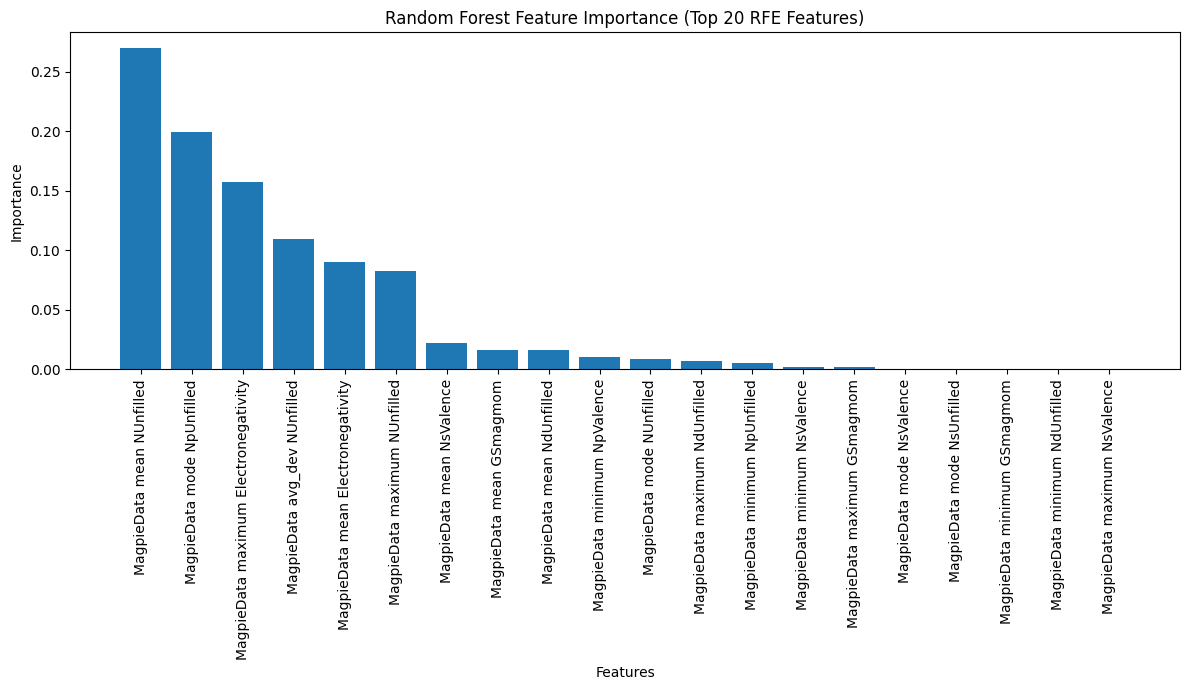


✅ S21 COMPLETED
Curated dataset:
curated_features_s21.csv

Feature importance:
s21_feature_importance.csv

Final curated shape: (4564, 22)


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# 1. Load S20 features and target dataset
# ============================================================

features = pd.read_csv("filtered_features_s20.csv")
cp = pd.read_csv("cleaned_cp_dataset.csv")

print("S20 Features shape:", features.shape)
print("CP dataset shape:", cp.shape)

# Check row alignment
assert len(features) == len(cp), "❌ Row counts do not match!"

# ============================================================
# 2. Create S21 dataset
# ============================================================

df = features.copy()

df.insert(0, "formula", cp["formula"].values)
df.insert(1, "target", cp["Cp"].values)

print("\nS21 dataset shape:", df.shape)
print("Target:", "Cp")
print("\nFirst 5 rows:")
print(df[["formula", "target"]].head())

# ============================================================
# 3. Prepare X and y
# ============================================================

X = df.drop(columns=["target", "formula"])
y = df["target"]

# Make sure everything is numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove any problematic rows
valid = X.notna().all(axis=1) & y.notna()

X = X.loc[valid]
y = y.loc[valid]
df = df.loc[valid].reset_index(drop=True)

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)

# ============================================================
# 4. Recursive Feature Elimination (RFE) with Ridge
# ============================================================

ridge = Ridge(alpha=1.0)

rfe = RFE(
    estimator=ridge,
    n_features_to_select=20
)

X_rfe = rfe.fit_transform(X, y)

top_features = X.columns[rfe.support_]

print("\n" + "="*60)
print("TOP 20 FEATURES SELECTED BY RFE")
print("="*60)

for i, feature in enumerate(top_features, 1):
    print(f"{i:2}. {feature}")

# ============================================================
# 5. Random Forest Feature Importance
# ============================================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rfe, y)

importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

# ============================================================
# 6. Feature Importance Table
# ============================================================

importance_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)

print(importance_df.to_string(index=False))

# ============================================================
# 7. Feature Importance Plot
# ============================================================

plt.figure(figsize=(12, 7))

plt.title("Random Forest Feature Importance (Top 20 RFE Features)")

plt.bar(
    range(len(indices)),
    importances[indices]
)

plt.xticks(
    range(len(indices)),
    top_features[indices],
    rotation=90
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()

plt.show()

# ============================================================
# 8. Save final curated S21 dataset
# ============================================================

df_curated = df[
    ["formula", "target"] + list(top_features)
]

df_curated.to_csv(
    "curated_features_s21.csv",
    index=False
)

# Also save feature importance
importance_df.to_csv(
    "s21_feature_importance.csv",
    index=False
)

print("\n" + "="*60)
print("✅ S21 COMPLETED")
print("="*60)

print("Curated dataset:")
print("curated_features_s21.csv")

print("\nFeature importance:")
print("s21_feature_importance.csv")

print("\nFinal curated shape:", df_curated.shape)